# Генерация синтетических данных с использованием Faker

In [4]:
!pip install faker

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\maxpl\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

In [6]:
# Инициализация генератора (русская локаль для реалистичных ФИО, адресов и т.д.)
fake = Faker('ru_RU')
Faker.seed(42)      # фиксируем seed для воспроизводимости
random.seed(42)

## Генерация синтетических данных для варианта "Сотрудники компании"

In [7]:
# DataFrame с отделами
def generate_departments(n):
   
    departments = []
    for i in range(1, n + 1):
        departments.append({
            'department_id': i,
            'name': fake.unique.job() + ' отдел',  # уникальное название
            'location': fake.city()
        })
    return pd.DataFrame(departments)

# DataFrame с должностями и диапазоном зарплат
def generate_positions(n: int) -> pd.DataFrame:
    
    positions = []
    for i in range(1, n + 1):
        min_salary = random.randint(30000, 60000)
        max_salary = min_salary + random.randint(20000, 80000)
        positions.append({
            'position_id': i,
            'name': fake.unique.job(),
            'min_salary': min_salary,
            'max_salary': max_salary
        })
    return pd.DataFrame(positions)

# генерируем сотрудников со случайными атрибутами
def generate_employees(n: int, department_ids: list, position_ids: list) -> pd.DataFrame:
    
    employees = []
    for emp_id in range(1, n + 1):        
        first_name = fake.first_name()
        last_name = fake.last_name()
        patronymic = fake.middle_name()
        birth_date = fake.date_of_birth(minimum_age=18, maximum_age=70)
        phone = fake.phone_number()
        email = fake.email()
        address = fake.address().replace('\n', ', ')
        
        # дата найма: не раньше 18-летия и не позже сегодняшнего дня
        min_hire_date = birth_date + timedelta(days=18*365)
        hire_date = fake.date_between(start_date=min_hire_date, end_date='today')
        
        # статус -  active / terminated (10% уволены)
        status = random.choices(['active', 'terminated'], weights=[0.9, 0.1])[0]
        
        # выбор отдела и должности
        department_id = random.choice(department_ids)
        position_id = random.choice(position_ids)
        
        # зарплата     
        salary = random.randint(40000, 150000)
        
        employees.append({
            'employee_id': emp_id,
            'last_name': last_name,
            'first_name': first_name,
            'patronymic': patronymic,
            'birth_date': birth_date,
            'gender': random.choice(['М', 'Ж']),
            'address': address,
            'phone': phone,
            'email': email,
            'hire_date': hire_date,
            'status': status,
            'department_id': department_id,
            'position_id': position_id,
            'salary': salary
        })
    return pd.DataFrame(employees)

# создать историю зарплат на основе данных сотрудников
def generate_salary_history(employees_df: pd.DataFrame, avg_records: int = 3):    
    history = []
    record_id = 1
    
    for _, emp in employees_df.iterrows():
        emp_id = emp['employee_id']
        hire_date = emp['hire_date']
        current_salary = emp['salary']
        
        # количество изменений (0 – если сотрудник только нанят и ещё не было изменений)
        num_changes = random.choices([0, 1, 2, 3, 4], weights=[0.2, 0.3, 0.3, 0.1, 0.1])[0]
        
        # генерируем даты изменений (после hire_date и до сегодня)
        change_dates = sorted([fake.date_between(start_date=hire_date, end_date='today') 
                               for _ in range(num_changes)])
        
        # начальная зарплата при найме (можно сделать немного отличающейся от текущей)
        #  будем считать, что первая запись – это зарплата при найме,
        # а последующие – повышения.
        if num_changes == 0:
            # Если изменений не было, всё равно добавим одну запись (начальная)
            history.append({
                'history_id': record_id,
                'employee_id': emp_id,
                'change_date': hire_date,
                'new_salary': current_salary
            })
            record_id += 1
        else:
            # генерируем возрастающие зарплаты
            salary_values = sorted([random.randint(30000, current_salary) for _ in range(num_changes)])
            # добавляем текущую зарплату как последнюю
            salary_values.append(current_salary)
            # даты: hire_date и change_dates
            all_dates = [hire_date] + change_dates
            for i in range(len(all_dates)):
                history.append({
                    'history_id': record_id,
                    'employee_id': emp_id,
                    'change_date': all_dates[i],
                    'new_salary': salary_values[i]
                })
                record_id += 1
    return pd.DataFrame(history)

In [8]:
N_DEPARTMENTS = 10
N_POSITIONS = 20
N_EMPLOYEES = 500

In [9]:
departments_df = generate_departments(N_DEPARTMENTS)
positions_df = generate_positions(N_POSITIONS)
employees_df = generate_employees(
    N_EMPLOYEES,
    departments_df['department_id'].tolist(),
    positions_df['position_id'].tolist()
)

In [10]:
departments_df

,department_id,name,location
0,1,Диетолог отдел,клх Кырен
1,2,Метеоролог отдел,п. Волоколамск
2,3,Гепатолог отдел,г. Артем
3,4,Гомеопат отдел,п. Териберка
4,5,Бактериолог отдел,клх Усинск
5,6,Танцор отдел,с. Чикола
6,7,Нотариус отдел,ст. Ессентуки
7,8,Тележурналист отдел,к. Ельня
8,9,Литейщик отдел,г. Видное
9,10,Сиделка отдел,к. Нефедова


In [11]:
positions_df

,position_id,name,min_salary,max_salary
0,1,Мясник,50952,78248
1,2,Борт-радист,30819,99417
2,3,Философ,39012,75061
3,4,Доярка,37314,66458
4,5,Семейный врач,54132,80849
5,6,Врач скорой помощи,52174,120714
6,7,Ортопед,59234,114975
7,8,Реставратор,32848,91546
8,9,Композитор,43825,65907
9,10,Военный прокурор,30976,57116


In [12]:
employees_df

,employee_id,last_name,first_name,patronymic,birth_date,gender,address,phone,email,hire_date,status,department_id,position_id,salary
0,1,Гаврилов,Мина,Кузьминична,1973-06-23,М,"к. Бологое, пер. Островского, д. 77, 242388",+7 928 327 64 83,tatjana_03@example.org,2009-05-05,active,7,11,76421
1,2,Григорьева,Ольга,Федотович,1995-01-07,Ж,"д. Красногорск (Моск.), ш. Заречное, д. 684 ст...",8 532 871 01 22,erjabova@example.com,2023-08-23,active,6,4,52156
2,3,Крюкова,Лаврентий,Егоровна,1989-11-09,М,"п. Хасавюрт, ул. Вахитова, д. 382, 824896",83252880957,makarovamaja@example.com,2015-01-19,active,6,20,74671
3,4,Лукина,Тимур,Николаевна,2002-04-03,М,"г. Яхрома, алл. Профсоюзная, д. 951, 473829",+7 (465) 787-1331,adrian_98@example.org,2025-02-21,active,9,4,89615
4,5,Мартынов,Савватий,Станиславовна,1987-06-30,М,"п. Уварово, алл. Челюскинцев, д. 84 к. 81, 080132",8 311 656 67 01,maslovalukija@example.org,2019-04-23,active,10,12,115674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Кузнецова,Твердислав,Теймуразович,1992-03-10,Ж,"с. Кажим, бул. Ручейный, д. 1 стр. 1, 669579",+7 (996) 872-25-89,semendementev@example.org,2010-10-30,active,4,16,112173
496,497,Фомина,Амвросий,Валерьевич,1966-09-26,М,"клх Котельнич, алл. Угольная, д. 4/4 стр. 356,...",+78255442867,ikarpov@example.com,1996-10-29,active,8,16,100401
497,498,Гуляев,Мефодий,Владленович,1994-06-20,Ж,"к. Ардон, пр. Механический, д. 9/6 стр. 895, 4...",+7 (693) 358-95-13,vatslav_2008@example.net,2014-06-30,active,6,6,58344
498,499,Корнилова,Евдокия,Якубович,1994-07-28,М,"п. Партизанск, ул. 40 лет Победы, д. 8 к. 455,...",+7 179 720 38 59,karpevseev@example.org,2020-08-26,active,9,2,108674


In [13]:
# Генерация истории зарплат
salary_history_df = generate_salary_history(employees_df, avg_records=3)
salary_history_df

,history_id,employee_id,change_date,new_salary
0,1,1,2009-05-05,71333
1,2,1,2023-11-29,76421
2,3,2,2023-08-23,34948
3,4,2,2025-02-14,52156
4,5,3,2015-01-19,74671
...,...,...,...,...
1291,1292,498,2022-08-28,57426
1292,1293,498,2024-03-17,58344
1293,1294,499,2020-08-26,89827
1294,1295,499,2022-10-06,108674


In [14]:
# Сохранение в CSV
departments_df.to_csv('departments.csv', index=False)
positions_df.to_csv('positions.csv', index=False)
employees_df.to_csv('employees.csv', index=False)
salary_history_df.to_csv('salary_history.csv', index=False)

# Задание на самостоятельную работу
Создать синтетический набор данных, сохранить его в csv файлы, построить на основе данных онтологию, вывести онтограф.




### Вариант 7. Транспортные средства и штрафы
Сущности:
- Владелец ТС: id, ФИО, водительское удостоверение (серия, номер), адрес, телефон.
- Автомобиль: id, госномер, марка, модель, год выпуска, VIN, цвет, id владельца.
- Штраф: id, id автомобиля, дата, статья нарушения, сумма, статус (оплачен/не оплачен).
- Страховой полис: id, id автомобиля, компания, дата начала, дата окончания, стоимость.

Объём: 1000 владельцев, 1200 автомобилей (некоторые владеют несколькими), 5000 штрафов, 1500 полисов.

Онтология:
- Классы: Владелец, Автомобиль, Штраф, Полис.
- Связи: владелец владеет автомобилями, автомобиль имеет штрафы и страховки.



In [15]:
print(dir(fake))

['__annotations__', '__class__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_factories', '_factory_map', '_locales', '_map_provider_method', '_optional_proxy', '_select_factory', '_select_factory_choice', '_select_factory_distribution', '_unique_proxy', '_weights', 'aba', 'add_provider', 'address', 'administrative_unit', 'am_pm', 'android_platform_token', 'ascii_company_email', 'ascii_email', 'ascii_free_email', 'ascii_safe_email', 'bank', 'bank_country', 'bban', 'bic', 'binary', 'boolean', 'bothify', 'bs', 'building_number', 'businesses_inn', 'businesses_ogrn', 'cache_pattern', 'catch_phrase', 'century', 'checking_account', 

In [16]:
print(fake.vin())

EBLUBDZJ9V15G9919


In [17]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

# Инициализация генератора с русской локалью для реалистичных ФИО, адресов и номеров машин
fake = Faker('ru_RU')

# Фиксируем seed для того, чтобы при каждом запуске данные генерировались одинаково
Faker.seed(42)      
random.seed(42)

In [18]:
#  Владельцы ТС
def generate_owners(n) -> pd.DataFrame:
    owners = []
    for i in range(1, n + 1):
        owners.append({
            'owner_id': i,
            'full_name': fake.name(), # Случайное ФИО
            # Генерируем серию (4 цифры) и номер (6 цифр) прав
            'driver_license': f"{random.randint(1000, 9999)} {random.randint(100000, 999999)}",
            # Адрес с удалением переносов строк для аккуратного вида
            'address': fake.address().replace('\n', ', '),
            'phone': fake.phone_number()
        })
    return pd.DataFrame(owners)

# Автомобили
def generate_cars(n, owner_ids) -> pd.DataFrame:
    cars = []
    # Небольшой словарь реалистичных марок и моделей
    brands_models = {
        'Lada': ['Vesta', 'Granta', 'Niva'],
        'Toyota': ['Camry', 'Corolla', 'RAV4'],
        'Kia': ['Rio', 'Sportage', 'Optima'],
        'Hyundai': ['Solaris', 'Creta', 'Tucson'],
        'Volkswagen': ['Polo', 'Tiguan', 'Jetta', 'Golf']
    }
    
    for i in range(1, n + 1):
        brand = random.choice(list(brands_models.keys()))
        model = random.choice(brands_models[brand])
        
        cars.append({
            'car_id': i,
            'license_plate': fake.license_plate(), # Случайный российский госномер
            'brand': brand,
            'model': model,
            'year': random.randint(2000, 2026),    # Год выпуска
            'vin': fake.vin(),                     # Уникальный VIN-код
            'color': fake.color_name(),
            'owner_id': random.choice(owner_ids) #Выбираем случайного водителя
            
        })
    return pd.DataFrame(cars)

#  Штрафы
def generate_fines(n, car_ids) -> pd.DataFrame:
    fines = []
    # Виды нарушений и базовые суммы штрафов
    violations = [
        ("Превышение скорости (12.9 ч.2 КоАП)", 500),
        ("Проезд на запрещающий сигнал (12.12 ч.1 КоАП)", 1000),
        ("Нарушение правил парковки (12.19 КоАП)", 1500),
        ("Выезд на встречную полосу (12.15 ч.4 КоАП)", 5000),
        ("Непристегнутый ремень (12.6 КоАП)", 1000)
    ]
    
    for i in range(1, n + 1):
        violation, amount = random.choice(violations)
        fines.append({
            'fine_id': i,
            'car_id': random.choice(car_ids), # Привязываем штраф к случайному автомобилю
            'date': fake.date_between(start_date='-3y', end_date='today'), # Штрафы за последние 3 года
            'violation': violation, 
            'amount': amount, 
            
            'status': random.choices(['оплачен', 'не оплачен'], weights=[0.7, 0.3])[0] # 70% оплачено, 30% не оплачено
        })
    return pd.DataFrame(fines)

#  Страховые полисы 
def generate_policies(n, car_ids) -> pd.DataFrame:
    policies = []
    companies = ['Росгосстрах', 'АльфаСтрахование', 'Ингосстрах', 'Т-Страхование']
    
    for i in range(1, n + 1):
        # Полис мог быть оформлен в любой день за последние 2 года
        start_date = fake.date_between(start_date='-2y', end_date='today')
        # Действует ровно 1 год
        end_date = start_date + timedelta(days=365) 
        
        policies.append({
            'policy_id': i,
            'car_id': random.choice(car_ids),
            'company': random.choice(companies),
            'start_date': start_date,
            'end_date': end_date,
            'cost': random.randint(5000, 25000) # Случайная стоимость от 5 до 25 тыс. руб.
        })
    return pd.DataFrame(policies)

In [19]:
# Указываем требуемые в задании объемы данных
N_OWNERS = 1000
N_CARS = 1200
N_FINES = 5000
N_POLICIES = 1500

#  Генерируем владельцев
owners_df = generate_owners(N_OWNERS)

# Генерируем авто, передавая список ID владельцев для связи
cars_df = generate_cars(N_CARS, owners_df['owner_id'].tolist())

# Генерируем штрафы, привязывая их к ID существующих автомобилей
fines_df = generate_fines(N_FINES, cars_df['car_id'].tolist())

# Генерируем страховые полисы для автомобилей
policies_df = generate_policies(N_POLICIES, cars_df['car_id'].tolist())



In [20]:

owners_df.to_csv('owners.csv', index=False)
cars_df.to_csv('cars.csv', index=False)
fines_df.to_csv('fines.csv', index=False)
policies_df.to_csv('policies.csv', index=False)


In [21]:
owners_df

,owner_id,full_name,driver_license,address,phone
0,1,Козлова Ирина Ефимовна,2824 126225,"клх Волоколамск, бул. Базарный, д. 1/1 стр. 93...",84026542351
1,2,Белов Мирон Изотович,5506 356787,"клх Сибай, ул. Циолковского, д. 684 стр. 11, 4...",8 (525) 534-19-28
2,3,Сорокина Октябрина Мироновна,4657 246316,"клх Мураши, алл. Речная, д. 7, 139537",8 724 238 84 96
3,4,Милица Михайловна Полякова,2679 809570,"г. Барнаул, алл. Большая, д. 2/7, 978480",+7 845 146 27 04
4,5,Дарья Сергеевна Сысоева,9935 191161,"ст. Терскол, алл. Амурская, д. 3 стр. 895, 154303",81171822782
...,...,...,...,...,...
995,996,Валентина Макаровна Прохорова,7955 182760,"г. Карачаевск, пр. Менделеева, д. 408, 761289",8 (993) 074-6113
996,997,Дроздова Элеонора Романовна,8055 731718,"г. Яшкуль, бул. Льва Толстого, д. 933 к. 9/9, ...",8 818 439 76 30
997,998,Самсонова Татьяна Андреевна,3956 671971,"п. Тайшет, наб. Строителей, д. 6 стр. 5/5, 107692",8 265 434 75 91
998,999,Новикова Иванна Ефимовна,5813 436814,"д. Томари, бул. Трактовый, д. 7/6 к. 8, 756816",8 (843) 407-30-71


In [22]:
cars_df.head()

,car_id,license_plate,brand,model,year,vin,color,owner_id
0,1,003CD1 25,Kia,Optima,2009,SLCAWFLM40G4C1497,Шоколадный,314
1,2,KM714 74,Hyundai,Tucson,2022,M3FNLPNV1T8XG0200,Черный,437
2,3,ОM594 799,Toyota,RAV4,2014,S8A7F60X0VS700650,Васильковый,360
3,4,СУ056 52,Hyundai,Solaris,2023,JTNF1GPP449TD5595,Сливовый,891
4,5,ОA7789 154,Kia,Optima,2013,DE9YTC4G0BFSR6008,Пурпурный,282


In [23]:
fines_df.head()

,fine_id,car_id,date,violation,amount,status
0,1,77,2025-01-25,Нарушение правил парковки (12.19 КоАП),1500,не оплачен
1,2,782,2025-03-30,Непристегнутый ремень (12.6 КоАП),1000,оплачен
2,3,685,2025-03-06,Превышение скорости (12.9 ч.2 КоАП),500,оплачен
3,4,854,2025-07-20,Выезд на встречную полосу (12.15 ч.4 КоАП),5000,не оплачен
4,5,465,2025-11-16,Превышение скорости (12.9 ч.2 КоАП),500,не оплачен


In [24]:
policies_df.head()

,policy_id,car_id,company,start_date,end_date,cost
0,1,1170,Т-Страхование,2025-01-29,2026-01-29,9229
1,2,126,АльфаСтрахование,2026-01-15,2027-01-15,8773
2,3,981,Росгосстрах,2026-01-18,2027-01-18,20693
3,4,670,Ингосстрах,2025-06-19,2026-06-19,21992
4,5,713,АльфаСтрахование,2025-06-20,2026-06-20,14406


In [ ]:
from owlready2 import *
import pandas as pd

# Создаем онтологию
onto = get_ontology("http://example.org/traffic_ontology_ru.owl")

with onto:
    class Владелец(Thing):
        pass

    class Автомобиль(Thing):
        pass

    class Штраф(Thing):
        pass

    class СтраховойПолис(Thing):
        pass

    # определяем связи
    class владеет_автомобилем(ObjectProperty):
        domain    = [Владелец]
        range     = [Автомобиль]

    class закреплен_за_автомобилем(ObjectProperty):
        domain    = [Штраф]
        range     = [Автомобиль]
        inverse_property = None # можно настроить обратную связь позже

    class привязан_к_автомобилю(ObjectProperty):
        domain    = [СтраховойПолис]
        range     = [Автомобиль]

    # атрибуты
    # Для Владельца
    class фио(DataProperty):
        domain = [Владелец]; range = [str]
    class номер_прав(DataProperty):
        domain = [Владелец]; range = [str]
    class адрес_проживания(DataProperty):
        domain = [Владелец]; range = [str]
    class контактный_телефон(DataProperty):
        domain = [Владелец]; range = [str]

    # Для Автомобиля
    class госномер(DataProperty):
        domain = [Автомобиль]; range = [str]
    class марка(DataProperty):
        domain = [Автомобиль]; range = [str]
    class модель(DataProperty):
        domain = [Автомобиль]; range = [str]
    class год_выпуска(DataProperty):
        domain = [Автомобиль]; range = [int]
    class вин_номер(DataProperty):
        domain = [Автомобиль]; range = [str]
    class цвет_кузова(DataProperty):
        domain = [Автомобиль]; range = [str]

    # Для Штрафа
    class дата_нарушения(DataProperty):
        domain = [Штраф]; range = [str]
    class статья_коап(DataProperty):
        domain = [Штраф]; range = [str]
    class сумма_штрафа(DataProperty):
        domain = [Штраф]; range = [int]
    class статус_оплаты(DataProperty):
        domain = [Штраф]; range = [str]

    # Для Полиса
    class страховая_компания(DataProperty):
        domain = [СтраховойПолис]; range = [str]
    class дата_начала(DataProperty):
        domain = [СтраховойПолис]; range = [str]
    class дата_окончания(DataProperty):
        domain = [СтраховойПолис]; range = [str]
    class стоимость_полиса(DataProperty):
        domain = [СтраховойПолис]; range = [int]





In [ ]:



владельцы_инстансы = {}
авто_инстансы = {}

with onto:
    # Заполняем владельцев
    for _, row in owners_df.iterrows():
        человек = Владелец(f"Владелец_{row['owner_id']}")
        человек.фио = [row['full_name']]
        человек.номер_прав = [row['driver_license']]
        человек.адрес_проживания = [row['address']]
        человек.контактный_телефон = [row['phone']]
        владельцы_инстансы[row['owner_id']] = человек

    # Заполняем автомобили
    for _, row in cars_df.iterrows():
        машина = Автомобиль(f"Авто_{row['car_id']}")
        машина.госномер = [row['license_plate']]
        машина.марка = [row['brand']]
        машина.модель = [row['model']]
        машина.год_выпуска = [row['year']]
        машина.вин_номер = [row['vin']]
        машина.цвет_кузова = [row['color']]
        
        # Связь с владельцем
        хозяин = владельцы_инстансы.get(row['owner_id'])
        if хозяин:
            хозяин.владеет_автомобилем.append(машина)
            
        авто_инстансы[row['car_id']] = машина

    # Заполняем штрафы
    for _, row in fines_df.iterrows():
        квитанция = Штраф(f"Штраф_{row['fine_id']}")
        квитанция.дата_нарушения = [str(row['date'])]
        квитанция.статья_коап = [row['violation']]
        квитанция.сумма_штрафа = [row['amount']]
        квитанция.статус_оплаты = [row['status']]
        
        # Привязка к авто
        машина = авто_инстансы.get(row['car_id'])
        if машина:
            квитанция.закрепилен_за_автомобилем = [машина]

    # Заполняем полисы
    for _, row in policies_df.iterrows():
        документ = СтраховойПолис(f"Полис_{row['policy_id']}")
        документ.страховая_компания = [row['company']]
        документ.дата_начала = [str(row['start_date'])]
        документ.дата_окончания = [str(row['end_date'])]
        документ.стоимость_полиса = [row['cost']]
        
        # Привязка к авто
        машина = авто_инстансы.get(row['car_id'])
        if машина:
            документ.привязан_к_автомобилю = [машина]

In [ ]:
def print_traffic_mindmap():
    print("\n" + "="*50)
    print("="*50)
    
    # проверка
    for owner in list(onto.Владелец.instances())[:5]:
        owner_name = owner.фио[0]
        print(f"\nВладелец: {owner_name}")
        
        cars = list(owner.владеет_автомобилем)
        
        if not cars:
            print()
            continue
            
        for car in cars:
            brand = car.марка[0]
            model = car.модель[0]
            plate = car.госномер[0]
            print(f"  Автомобиль: {brand} {model} [{plate}]")
            
            # Собираем штрафы этой машины
            fines = [f for f in onto.Штраф.instances() if car in f.закреплен_за_автомобилем]
            if fines:
                print("Штрафы:")
                for fine in fines:
                    print(f"     - {fine.статья_коап[0]} | {fine.сумма_штрафа[0]} руб.")
            else:
                print("Штрафы: нет")
                
            # Собираем полисы этой машины
            policies = [p for p in onto.СтраховойПолис.instances() if car in p.привязан_к_автомобилю]
            if policies:
                print("Страховки:")
                for policy in policies:
                    print(f"     - {policy.страховая_компания[0]} | {policy.стоимость_полиса[0]} руб.")
            else:
                print("Страховки: нет")

print_traffic_mindmap()


ДОСЬЕ: ВЛАДЕЛЬЦЫ, АВТО, ШТРАФЫ И ПОЛИСЫ

Владелец: Козлова Ирина Ефимовна
  Автомобиль: Toyota Corolla [6176УН 159]
    Штрафы: нет
    Страховки:
     - Росгосстрах | 22406 руб.

Владелец: Белов Мирон Изотович
  Автомобилей: нет

Владелец: Сорокина Октябрина Мироновна
  Автомобиль: Hyundai Creta [1490ТХ 68]
    Штрафы: нет
    Страховки:
     - Т-Страхование | 10163 руб.
  Автомобиль: Hyundai Creta [ОХ5121 174]
    Штрафы: нет
 Страховки: нет
  Автомобиль: Lada Niva [Х4055 60]
    Штрафы: нет
 Страховки: нет

Владелец: Милица Михайловна Полякова
  Автомобилей: нет

Владелец: Дарья Сергеевна Сысоева
  Автомобиль: Hyundai Creta [7953ОB 90]
    Штрафы: нет
    Страховки:
     - Росгосстрах | 16236 руб.
  Автомобиль: Volkswagen Tiguan [О7224 763]
    Штрафы: нет
    Страховки:
     - Ингосстрах | 20765 руб.
     - Т-Страхование | 9338 руб.
     - Т-Страхование | 10957 руб.


Онтограф


In [30]:
import networkx as nx

In [31]:
import matplotlib.pyplot as plt

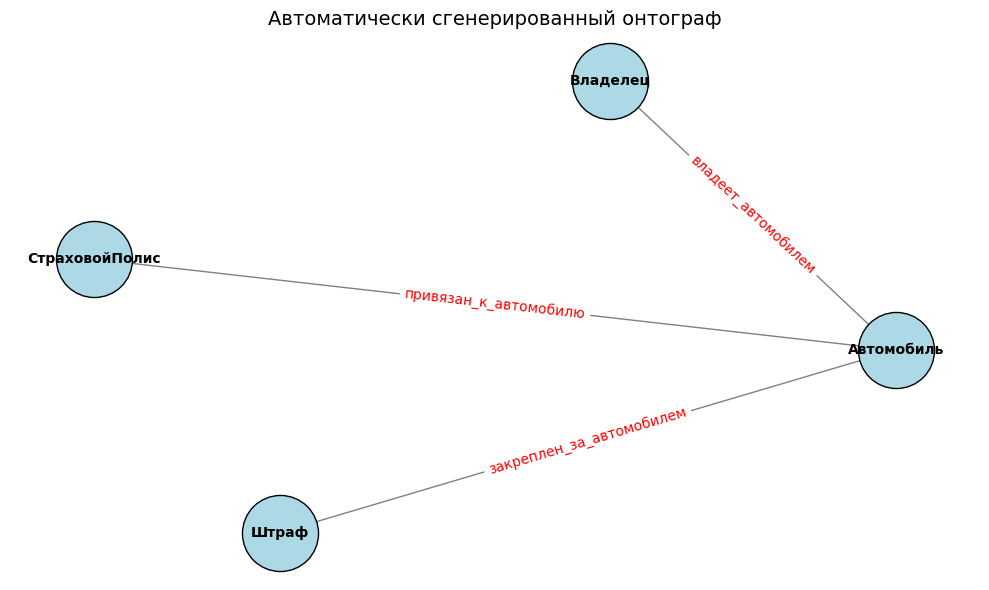

In [ ]:
# Загружаем онтологию
onto = get_ontology("онтология.owl").load()

# Создаем пустой граф
G = nx.DiGraph()

# Проходим по всем классам в онтологии
for cls in list(onto.classes()):
    # Добавляем класс как узел
    G.add_node(cls.name)
    
    # Ищем все объектные свойства (связи), где этот класс является доменом (источником)
    for prop in list(onto.object_properties()):
        if cls in prop.domain:
            # Ищем, куда ведет эта связь 
            for target in prop.range:
                # Добавляем связь в граф
                if hasattr(target, 'name'):
                    G.add_edge(cls.name, target.name, label=prop.name)


plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42, k=2)

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20, edge_color='gray')

edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Автоматически сгенерированный онтограф", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()